# 04 基线模型（LightGBM）

**目标：**
1. 加载特征选择后的数据（110 列）
2. 用 StratifiedKFold 做交叉验证，训练 LightGBM
3. 得到基线 AUC 分数
4. 可视化特征重要性，精筛无用特征

## 1. 导入库与加载数据

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection  import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier

df = pd.read_csv("../data/processed/app_train_selected.csv")
df.columns
df.shape

(307511, 110)

## 2. 准备特征矩阵 X 和标签 y

In [2]:
X = df.drop(columns=["SK_ID_CURR", "TARGET"])
Y = df["TARGET"]

## 3. StratifiedKFold 交叉验证 + LightGBM 训练

**关键参数说明：**
- `n_splits=5`：5 折，每次用 80% 训练、20% 验证
- `shuffle=True`：打乱顺序，避免数据有时间顺序时折间分布差异大
- 每折结束后记录验证集 AUC，最终取平均

In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #进行5折然后每一折是2/8分
AUC_list = []
importance_list = []
for train_idx, val_idx in skf.split(X, Y):
    X_train = X.iloc[train_idx] 
    Y_train = Y.iloc[train_idx]
    X_val = X.iloc[val_idx]
    Y_val = Y.iloc[val_idx]
    model = LGBMClassifier()
    model.fit(X_train, Y_train)
    y_pred = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(Y_val, y_pred)
    print(f"AUC: {auc:.4f}")
    AUC_list.append(auc)
    importance_list.append(model.feature_importances_)

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017297 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10887
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 108
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
AUC: 0.7647
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012701 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10883
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 10

In [4]:
importance_df = pd.DataFrame(
    {
        "feature" : X.columns,     
        "importance" : np.mean(importance_list, axis=0)
    }
).sort_values("importance",ascending=False)
print(importance_df[importance_df["importance"] == 0])

                       feature  importance
20            FLAG_CONT_MOBILE         0.0
28  REG_REGION_NOT_LIVE_REGION         0.0
75            FLAG_DOCUMENT_20         0.0
64             FLAG_DOCUMENT_7         0.0
74            FLAG_DOCUMENT_19         0.0
72            FLAG_DOCUMENT_17         0.0
70            FLAG_DOCUMENT_15         0.0


## 4. 特征重要性可视化

LightGBM 训练后可以通过 `model.feature_importances_` 获取每个特征的重要性分数。  
我们把 5 折的重要性取平均，再按分数排序可视化。

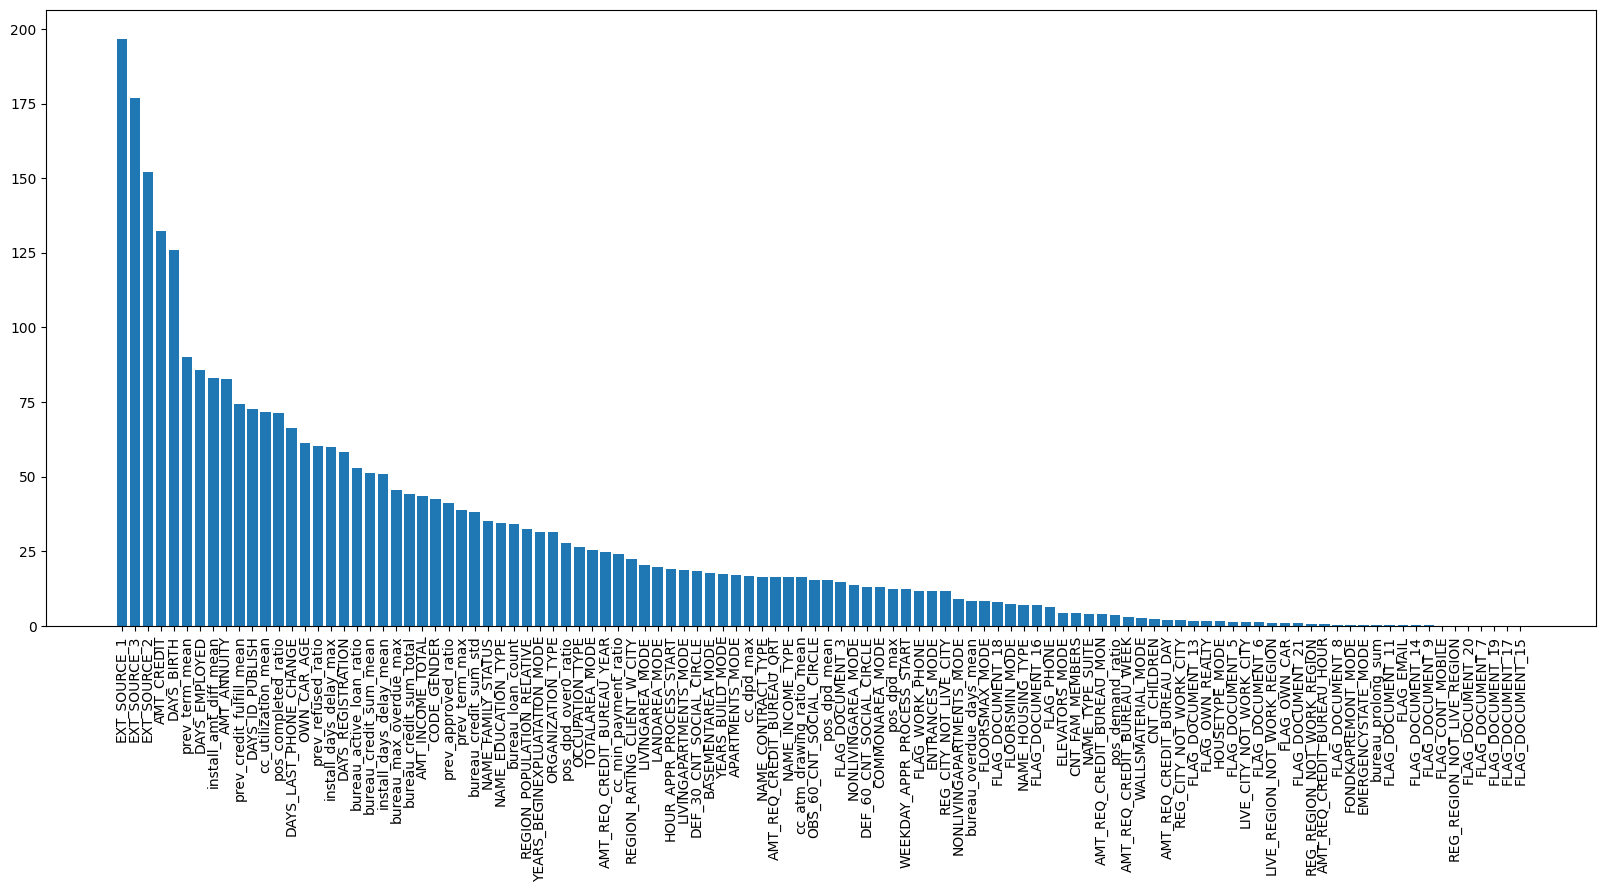

In [5]:
plt.figure(figsize=(20,8))
plt.bar(importance_df["feature"],importance_df["importance"])
plt.xticks(rotation = 90)
plt.show()

## 5. 精筛特征：删除重要性为 0 的特征

In [6]:
print(importance_df[importance_df["importance"] == 0])

                       feature  importance
20            FLAG_CONT_MOBILE         0.0
28  REG_REGION_NOT_LIVE_REGION         0.0
75            FLAG_DOCUMENT_20         0.0
64             FLAG_DOCUMENT_7         0.0
74            FLAG_DOCUMENT_19         0.0
72            FLAG_DOCUMENT_17         0.0
70            FLAG_DOCUMENT_15         0.0


## 6. 保存精筛后的特征数据

In [7]:
cols_to_drop = [
    'FLAG_CONT_MOBILE',
    'REG_REGION_NOT_LIVE_REGION',
    'FLAG_DOCUMENT_20',
    'FLAG_DOCUMENT_7',
    'FLAG_DOCUMENT_19',
    'FLAG_DOCUMENT_17',
    'FLAG_DOCUMENT_15'
]
df = df.drop(columns=cols_to_drop)
df.to_csv("../data/processed/app_train_final.csv",index=False)